# 5.5 Geographical Differences in Brexit Framing

### Go directly to:
- [Geographical Differences Analysis](#geographical-differences-analysis)

### Dataset Preparation

In [72]:
# Load libraries
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
import seaborn as sns

In [73]:
# Load CSV files from duckdb
df_con = pd.read_csv("constituencies_2025.csv", sep=";", on_bad_lines='skip', engine='python')
df_dem = pd.read_csv("Speaker_demographics.csv", sep=";", on_bad_lines='skip', engine='python')
df_chu = pd.read_csv("chunks.csv", sep=",", on_bad_lines='skip', engine='python')
df_spe = pd.read_csv("speeches.csv", sep=",", on_bad_lines='skip', engine='python')

# Print number of rows of each file
print("Rows in df_con:", len(df_con))
print("Rows in df_dem:", len(df_dem))
print("Rows in df_chu:", len(df_chu))
print("Rows in df_spe:", len(df_spe))

Rows in df_con: 650
Rows in df_dem: 1124
Rows in df_chu: 62847
Rows in df_spe: 32087


In [74]:
# Remove blank or missing twfy_id before merging
df_dem = df_dem[df_dem['twfy_id'].notna()]

# Remove blank or missing twfy_id before merging
df_spe = df_spe[df_spe['twfy_id'].notna()]

# Print number of rows with speaker ID
print("Rows in df_con:", len(df_con))
print("Rows in df_dem:", len(df_dem))
print("Rows in df_chu:", len(df_chu))
print("Rows in df_spe:", len(df_spe))

Rows in df_con: 650
Rows in df_dem: 1094
Rows in df_chu: 62847
Rows in df_spe: 31560


## Enriching Chunk Dataframe with Metadata

In [75]:
# Merge Speaker demographics and constituencies and selecting only the columns I need from df_con
const_cols = [
    'constituency',
    'nation',
    'region',
    'area',
    'density',
    'center_lat',
    'center_lon'
]

# Merge speaker demographics with constituency info
df_dem = df_dem.merge(
    df_con[const_cols],
    left_on='Constituency',
    right_on='constituency',
    how='left'             
)

# Print merged df
df_dem.head()

,twfy_id,First name,Last name,Party,Constituency,person_id,brexit_vote,Fullname,Gender,HouseStartYear,HouseEndYear,Birthdate,constituency,nation,region,area,density,center_lat,center_lon
0,10900.0,Hywel,Francis,Labour,Aberafan Maesteg,uk.org.publicwhip/member/10900,NaN,Hywel Francis,M,2001.0,2015.0,06/06/1946,Aberafan Maesteg,Wales,Wales,"249,5081731","279,818489","51,60820598","-3,701807387"
1,25297.0,Stephen,Kinnock,Labour,Aberafan Maesteg,uk.org.publicwhip/member/25297,remain,Stephen Kinnock,M,2015.0,NaN,01/01/1970,Aberafan Maesteg,Wales,Wales,"249,5081731","279,818489","51,60820598","-3,701807387"
2,10174.0,Frank,Doran,Labour,Aberdeen North,uk.org.publicwhip/member/10174,NaN,Frank Doran,M,1997.0,2015.0,13/04/1949,Aberdeen North,Scotland,Scotland,"103,5741812","742,4147518","57,18740967","-2,175601003"
3,25314.0,Kirsty,Blackman,Scottish National Party,Aberdeen North,uk.org.publicwhip/member/25314,NaN,Kirsty Blackman,F,2015.0,NaN,20/03/1986,Aberdeen North,Scotland,Scotland,"103,5741812","742,4147518","57,18740967","-2,175601003"
4,10032.0,Anne,Begg,Labour,Aberdeen South,uk.org.publicwhip/member/10032,NaN,Anne Begg,F,1997.0,2015.0,06/12/1955,Aberdeen South,Scotland,Scotland,"102,0155705","750,4736739","57,12365351","-2,171649568"


In [76]:
# Merge twfy_id from speech df to chunk df
df_chu = df_chu.merge(
    df_spe[['speech_id', 'twfy_id']],
    on='speech_id',
    how='left',
)
# Quick check
df_chu.head()

,chunk_id,speech_id,debate_id,speaker_name,speaker_party,debate_title,debate_date,chunk_text,chunk_index,total_chunks,...,char_count,chunking_method,assigned_user,frame_label,annotation_confidence,annotation_notes,created_at,updated_at,classification_timestamp,twfy_id
0,chunk_220102,uk.org.publicwhip/debate/2019-03-13b.364.6,uk.org.publicwhip/debate/2019-03-13b.345.0,Chris Leslie,NaN,SPRING STATEMENT,2019-03-13,It is a fundamental mistake for the Chancellor...,0,1,...,565,semantic,NaN,economic,NaN,NaN,2025-10-13 11:05:52.85417,2025-10-13 11:05:52.85417,2025-11-02 23:26:03.503761,10354
1,chunk_270431,uk.org.publicwhip/debate/2019-12-20a.146.6,uk.org.publicwhip/debate/2019-12-20a.146.0,Jonathan Edwards,NaN,European Union (Withdrawal Agreement) Bill,2019-12-20,The Bill contains provisions not to extend the...,0,1,...,236,semantic,NaN,powerlessness,NaN,NaN,2025-10-13 11:05:56.513287,2025-10-13 11:05:56.513287,2025-11-02 23:26:03.513426,24743
2,chunk_231421,uk.org.publicwhip/debate/2019-04-09c.213.0,uk.org.publicwhip/debate/2019-04-09c.205.0,Alan Duncan,NaN,EXITING THE EUROPEAN UNION (SANCTIONS),2019-04-09,I think the right hon. Lady may have misunders...,0,1,...,1197,semantic,NaN,none,NaN,NaN,2025-10-13 11:05:55.054923,2025-10-13 11:05:55.054923,2025-11-02 23:26:03.516645,10179
3,chunk_190859,uk.org.publicwhip/debate/2019-01-14b.834.2,uk.org.publicwhip/debate/2019-01-14b.823.3,Theresa May,NaN,LEAVING THE EU,2019-01-14,"Of course, the House will give its view tomorr...",0,1,...,593,semantic,NaN,economic,NaN,NaN,2025-10-13 11:05:52.342023,2025-10-13 11:05:52.342023,2025-11-02 23:26:03.520324,10426
4,chunk_101471,uk.org.publicwhip/debate/2017-11-20b.800.1,uk.org.publicwhip/debate/2017-11-20b.758.0,Anna Soubry,NaN,DUTIES OF CUSTOMS,2017-11-20,I am not going to repeat the excellent argumen...,2,5,...,664,semantic,NaN,conflict,NaN,NaN,2025-10-13 11:05:43.267617,2025-10-13 11:05:43.267617,2025-11-02 23:26:03.523197,24772


In [77]:
# Remove blank or missing twfy_id before merging
df_chu = df_chu[df_chu['twfy_id'].notna()]
print("Rows in df_chu:", len(df_chu))

Rows in df_chu: 62115


In [78]:
# Merge Speaker demographics and chunks based on column "twfy_id" selecting only the columns I need from df_dem
dem_cols = [
    "twfy_id",
    "First name",
    "Last name",
    "Party",
    'Constituency',
    "brexit_vote",
    "Gender",
    "HouseStartYear",
    "HouseEndYear",
    "Birthdate",
    'nation',
    'region',
    'area',
    'density',
    'center_lat',
    'center_lon'
]

df_chu['twfy_id'] = pd.to_numeric(df_chu['twfy_id'], errors='coerce').astype('Int64')
df_dem['twfy_id'] = pd.to_numeric(df_dem['twfy_id'], errors='coerce').astype('Int64')


# Merge speaker demographics with chunks, keeping all speakers, even if no constituency match
df_chu = df_chu.merge(
    df_dem[dem_cols],
    left_on='twfy_id',
    right_on='twfy_id',
    how='left'            
)

# Print merged df
df_chu.tail()

,chunk_id,speech_id,debate_id,speaker_name,speaker_party,debate_title,debate_date,chunk_text,chunk_index,total_chunks,...,Gender,HouseStartYear,HouseEndYear,Birthdate,nation,region,area,density,center_lat,center_lon
62110,chunk_320231,uk.org.publicwhip/debate/2022-12-20a.136.0,uk.org.publicwhip/debate/2022-12-20a.135.0,Peter Aldous,NaN,Annual Fisheries Negotiations with EU and Nort...,2022-12-20,My right hon. Friend highlighted the fact that...,1,3,...,M,2010.0,2024.0,26/08/1961,England,Eastern,"988,9201565","71,33032888","52,36271946","1,238507477"
62111,chunk_320233,uk.org.publicwhip/debate/2022-12-20a.139.1,uk.org.publicwhip/debate/2022-12-20a.135.0,Peter Grant,NaN,Annual Fisheries Negotiations with EU and Nort...,2022-12-20,I am surprised to hear the Minister say that h...,0,2,...,M,2015.0,2024.0,12/10/1960,Scotland,Scotland,"173,9471272","400,8919325","56,17661961","-3,19933604"
62112,chunk_320234,uk.org.publicwhip/debate/2022-12-20a.139.1,uk.org.publicwhip/debate/2022-12-20a.135.0,Peter Grant,NaN,Annual Fisheries Negotiations with EU and Nort...,2022-12-20,"Finally, I note that one big increase in quota...",1,2,...,M,2015.0,2024.0,12/10/1960,Scotland,Scotland,"173,9471272","400,8919325","56,17661961","-3,19933604"
62113,chunk_320235,uk.org.publicwhip/debate/2022-12-20a.195.0,uk.org.publicwhip/debate/2022-12-20a.175.0,Luke Evans,NaN,Christmas Adjournment,2022-12-20,I think this may be a first. If the House will...,0,2,...,M,2019.0,NaN,10/01/1983,England,East Midlands,"290,0237753","260,954468","52,61837363","-1,427094322"
62114,chunk_320236,uk.org.publicwhip/debate/2022-12-20a.195.0,uk.org.publicwhip/debate/2022-12-20a.175.0,Luke Evans,NaN,Christmas Adjournment,2022-12-20,The UK has also been successful in implementin...,1,2,...,M,2019.0,NaN,10/01/1983,England,East Midlands,"290,0237753","260,954468","52,61837363","-1,427094322"


In [79]:
# Remove unnecessary columns
df_final = df_chu.drop(columns=['debate_title', 'chunk_index', 'word_count', 'char_count', 'chunking_method', "assigned_user","annotation_confidence", "annotation_notes", "created_at", "updated_at", "classification_timestamp", "chunk_text", "total_chunks", "speaker_name", "speaker_party", "debate_id"])

In [80]:
# Remove unnecessary columns
df_final = df_chu.drop(columns=['debate_title', 'chunk_index', 'word_count', 'char_count', 'chunking_method', "assigned_user","annotation_confidence", "annotation_notes", "created_at", "updated_at", "classification_timestamp", "chunk_text", "total_chunks", "speaker_name", "speaker_party", "debate_id"])

# Check date formats
df_final['Birthdate'] = pd.to_datetime(df_final['Birthdate'], errors='coerce', dayfirst=True)
df_final['debate_date'] = pd.to_datetime(df_final['debate_date'], errors='coerce', dayfirst=True)

# Calculate age at speach based on birthdate for MPs
df_final['age_at_speech'] = (
    (df_final['debate_date'] - df_final['Birthdate']).dt.days / 365.25
).round(0)
df_final['age_at_speech'] = df_final['age_at_speech'].astype('Int64')

# Extract year from debate date
df_final['debate_year'] = df_final['debate_date'].dt.year

# Calculate parliamentary tenure of MP at speech
df_final['years_in_house_at_speech'] = (
    df_final['debate_year'] - df_final['HouseStartYear']
)
df_final.loc[df_final['years_in_house_at_speech'] < 0, 'years_in_house_at_speech'] = np.nan
df_final['years_in_house_at_speech'] = df_final['years_in_house_at_speech'].astype('Int64')

# Print df
df_final.head()

/var/folders/cr/_gv649nx5y3c2ghv3v23kr5c0000gn/T/ipykernel_6330/1129298684.py:6: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_final['debate_date'] = pd.to_datetime(df_final['debate_date'], errors='coerce', dayfirst=True)


,chunk_id,speech_id,debate_date,frame_label,twfy_id,First name,Last name,Party,Constituency,brexit_vote,...,Birthdate,nation,region,area,density,center_lat,center_lon,age_at_speech,debate_year,years_in_house_at_speech
0,chunk_220102,uk.org.publicwhip/debate/2019-03-13b.364.6,2019-03-13,economic,10354,Chris,Leslie,Labour/Co-operative,Nottingham East,remain,...,1972-06-28,England,East Midlands,"21,67565073","3475,189786","52,96518888","-1,140461389",47,2019,9
1,chunk_270431,uk.org.publicwhip/debate/2019-12-20a.146.6,2019-12-20,powerlessness,24743,Jonathan,Edwards,Independent,Caerfyrddin,NaN,...,1976-05-26,Wales,Wales,"2040,77046","35,61547044","51,9306504","-4,153879821",44,2019,9
2,chunk_231421,uk.org.publicwhip/debate/2019-04-09c.213.0,2019-04-09,none,10179,Alan,Duncan,Conservative,Rutland and Stamford,remain,...,1957-03-31,England,East Midlands,"960,0572818","73,8122624","52,68449397","-0,655618247",62,2019,27
3,chunk_190859,uk.org.publicwhip/debate/2019-01-14b.834.2,2019-01-14,economic,10426,Theresa,May,Conservative,Maidenhead,remain,...,1956-10-01,England,South East,"182,3841024","402,7927819","51,48149823","-0,743676633",62,2019,22
4,chunk_101471,uk.org.publicwhip/debate/2017-11-20b.800.1,2017-11-20,conflict,24772,Anna,Soubry,Conservative,Broxtowe,remain,...,1956-12-07,England,East Midlands,"60,72615129","1193,242095","52,97003344","-1,266782234",61,2017,7


## Geographical Differences Analysis

In [81]:
# ------------------------------------------------------------
# Analyze corpus coverage of geographic information and compute distribution of speech chunks per nation.
# ------------------------------------------------------------

# Work on a copy of the dataset
df_geo = df_final.copy()

# --- 1. Total corpus size ---
total_chunks = len(df_geo)

# --- 2. Keep only rows with valid nation information ---
df_geo_valid = df_geo.dropna(subset=['nation'])
total_valid = len(df_geo_valid)
coverage = total_valid / total_chunks * 100

print(f"Total chunks in corpus: {total_chunks:,}")
print(f"Chunks with valid nation info: {total_valid:,} ({coverage:.1f}%)")

# --- 3. Counts & percentages per nation ---
nation_counts = df_geo_valid['nation'].value_counts().sort_index()
nation_pct = (nation_counts / total_valid * 100)

nation_table = pd.DataFrame({
    'chunks': nation_counts,
    'pct_of_geo_corpus': nation_pct.round(2)
})

print("\nChunks per nation:")
display(nation_table)

# Convenience values for the four UK nations
eng_count = nation_counts.get('England', 0)
sco_count = nation_counts.get('Scotland', 0)
wal_count = nation_counts.get('Wales', 0)
ni_count  = nation_counts.get('Northern Ireland', 0)

eng_pct = nation_pct.get('England', 0.0)
sco_pct = nation_pct.get('Scotland', 0.0)
wal_pct = nation_pct.get('Wales', 0.0)
ni_pct  = nation_pct.get('Northern Ireland', 0.0)

# Count chunks without geographic label
other_chunks = total_chunks - total_valid
other_pct = other_chunks / total_chunks * 100
print(f"\nChunks without nation info: {other_chunks:,} ({other_pct:.1f}%)")


Total chunks in corpus: 62,115
Chunks with valid nation info: 60,907 (98.1%)

Chunks per nation:


,chunks,pct_of_geo_corpus
nation,,
England,44886,73.70
Northern Ireland,1828,3.00
Scotland,10596,17.40
Wales,3597,5.91



Chunks without nation info: 1,208 (1.9%)


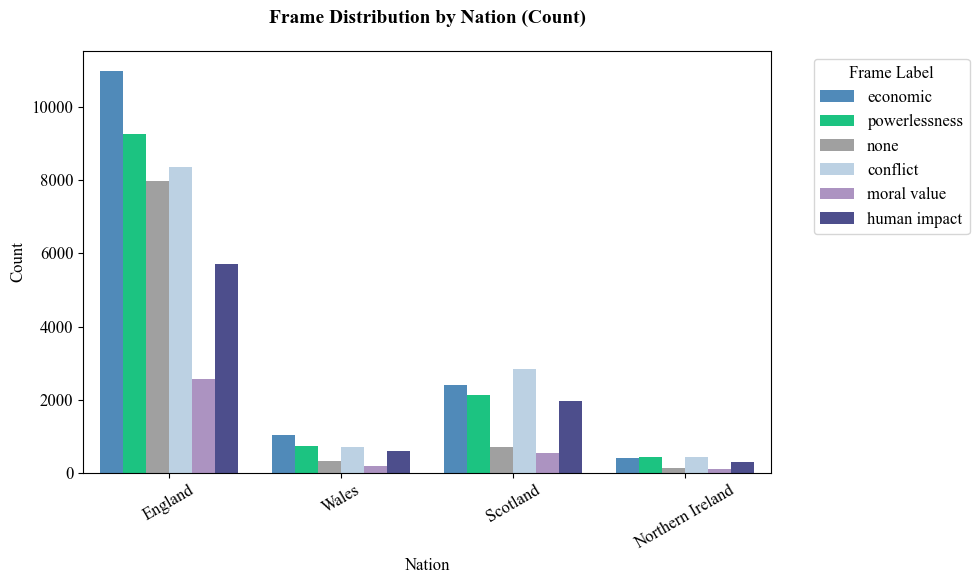

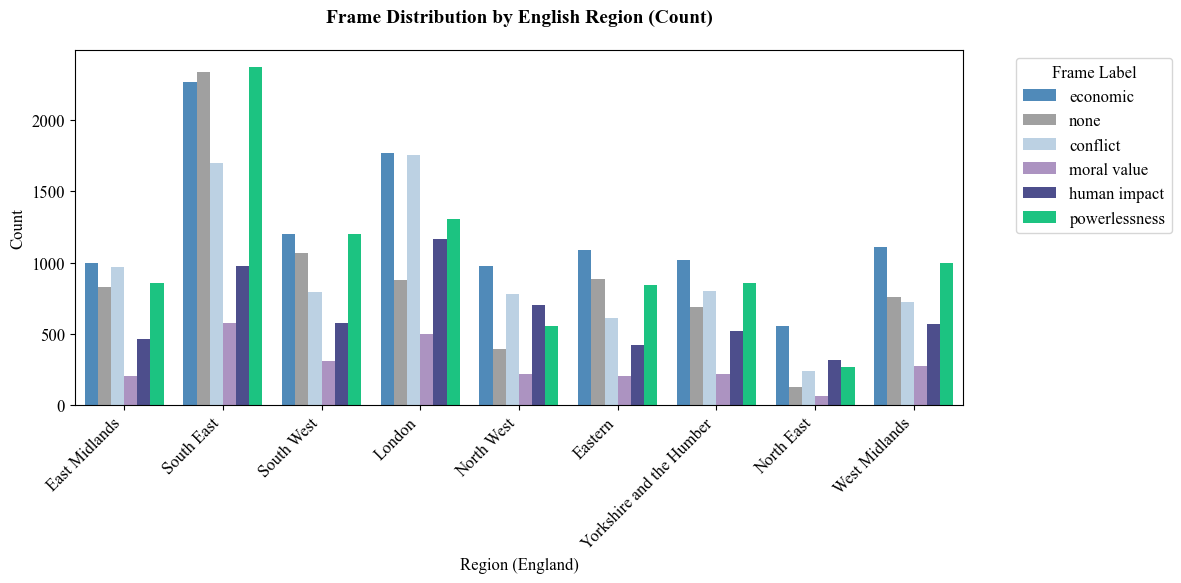

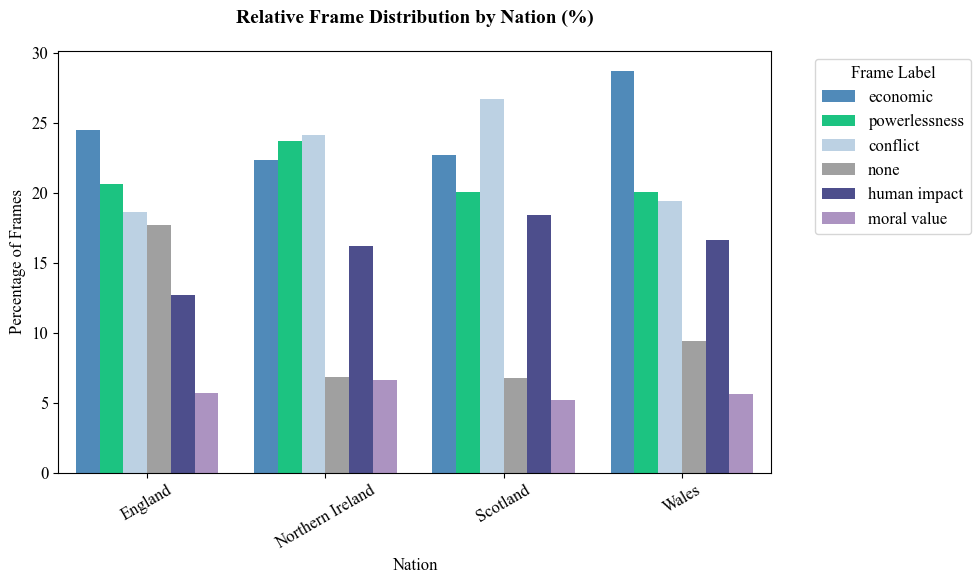

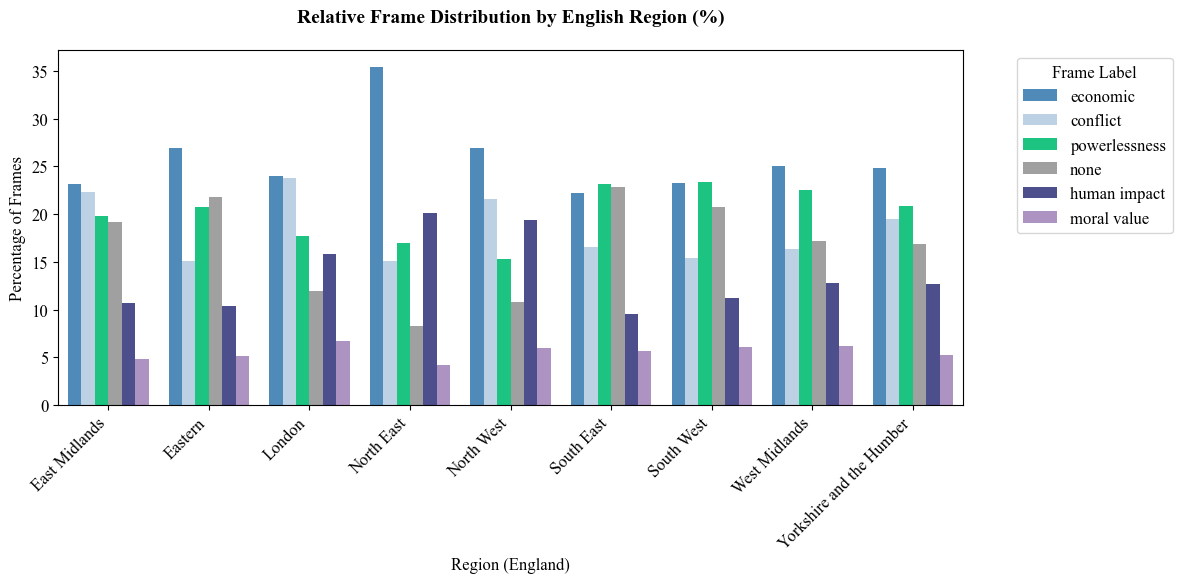

In [82]:
# ------------------------------------------------------------
# Compare frame distributions across UK nations and across the regions of England using separate visualizations.
# ------------------------------------------------------------

# Define Frame Colors
LIGHT_GREEN = "#B4F3D0"
GREEN = "#00DF87"
LIGHT_BLUE = "#B5D1EA"
SKY_BLUE = "#8ACFDF"
BLUE = "#3E8CCB"
DARK_BLUE = "#424496"
YELLOW_HIGHLIGHT = "#EFD292"
ORANGE_HIGHLIGHT = "#F79645"
PURPLE = "#AD8BC9"
DARK_GREY = "#4D4D4D"
MEDIUM_GREY = "#646464"
GREY = "#A0A0A0"
LIGHT_GREY = "#BFBFBF"
VERY_LIGHT_GREY = "#D9D9D9"

FRAME_COLORS = {
 "economic": BLUE,
 "powerlessness": GREEN,
 "conflict": LIGHT_BLUE,
 "none": GREY,
 "human impact": DARK_BLUE,
 "moral value": PURPLE,
}

# England subset (only valid nation rows)
df_england = df_geo_valid[df_geo_valid['nation'] == 'England'].copy()

# Percentage distribution of frames per nation
nation_pct = (
 df_geo_valid
 .groupby('nation')['frame_label']
 .value_counts(normalize=True)
 .mul(100)
 .rename('percentage')
 .reset_index()
)

# Percentage distribution of frames per English region
region_pct = (
 df_england
 .groupby('region')['frame_label']
 .value_counts(normalize=True)
 .mul(100)
 .rename('percentage')
 .reset_index()
)

# Set font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

# ------------------------------------------------------------
# Visualization 1: Frame Distribution by Nation (Count)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(
 data=df_geo_valid,
 x='nation',
 hue='frame_label',
 palette=FRAME_COLORS,
 ax=ax
)
ax.set_title('Frame Distribution by Nation (Count)', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Nation', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.tick_params(axis='x', rotation=30, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.legend(title='Frame Label', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize=12)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Visualization 2: Frame Distribution by English Region (Count)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(
 data=df_england,
 x='region',
 hue='frame_label',
 palette=FRAME_COLORS,
 ax=ax
)
ax.set_title('Frame Distribution by English Region (Count)', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Region (England)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.legend(title='Frame Label', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize=12)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Visualization 3: Relative Frame Distribution by Nation (%)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
 data=nation_pct,
 x='nation',
 y='percentage',
 hue='frame_label',
 palette=FRAME_COLORS,
 ax=ax
)
ax.set_title('Relative Frame Distribution by Nation (%)', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Nation', fontsize=12)
ax.set_ylabel('Percentage of Frames', fontsize=12)
ax.tick_params(axis='x', rotation=30, labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.legend(title='Frame Label', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize=12)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Visualization 4: Relative Frame Distribution by English Region (%)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
 data=region_pct,
 x='region',
 y='percentage',
 hue='frame_label',
 palette=FRAME_COLORS,
 ax=ax
)
ax.set_title('Relative Frame Distribution by English Region (%)', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Region (England)', fontsize=12)
ax.set_ylabel('Percentage of Frames', fontsize=12)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.legend(title='Frame Label', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize=12)
plt.tight_layout()
plt.show()

In [83]:
# ------------------------------------------------------------
# Conduct chi-square tests for each nation vs all other nations,to identify frames disproportionately associated with one region.
# ------------------------------------------------------------

ALPHA = 0.05          # significance threshold
EXCLUDE_NONE = True   # whether to exclude frame label "none"

# Prepare analysis dataset (only rows with valid nation)
df_ana = df_geo_valid.copy()

# Optional: remove "none" frames
if EXCLUDE_NONE:
    df_ana = df_ana[df_ana['frame_label'].str.lower() != 'none']

# Keep only rows with valid frame label
df_ana = df_ana.dropna(subset=['frame_label'])

# List of unique nations
nations = df_ana['nation'].unique()

# ------------------------------------------------------------
# Helper function: Cramér's V effect size
# ------------------------------------------------------------
def cramers_v(chi2, n, r, c):
    denom = n * (min(r - 1, c - 1))
    return np.sqrt(chi2 / denom) if denom > 0 else np.nan

# ------------------------------------------------------------
# Chi-square: compare each nation vs all others (binary test)
# ------------------------------------------------------------
results = []

for nat in nations:
    sub = df_ana.copy()
    
    # Create binary grouping variable
    sub['group'] = np.where(sub['nation'] == nat, nat, 'Other')
    
    # Contingency table
    contingency = pd.crosstab(sub['group'], sub['frame_label'])
    
    # Chi-square test
    chi2, p, dof, expected = chi2_contingency(contingency)
    n = contingency.values.sum()
    r, c = contingency.shape
    V = cramers_v(chi2, n, r, c)
    
    results.append({
        'Nation': nat,
        'Chi2': chi2,
        'P_value': p,
        'Cramers_V': V,
        'df': dof,
        'N': n,
        'significant': p < ALPHA
    })

# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------
nation_results = (
    pd.DataFrame(results)
    .sort_values('Chi2', ascending=False)
    .reset_index(drop=True)
)

display(
    nation_results.style.format({
        'Chi2': '{:.2f}',
        'P_value': '{:.3g}',
        'Cramers_V': '{:.3f}',
        'N': '{:,.0f}',
        'df': '{:.0f}'
    })
)

# Optional plain text output
print(nation_results[['Nation', 'Chi2', 'P_value', 'Cramers_V', 'df', 'N', 'significant']])


,Nation,Chi2,P_value,Cramers_V,df,N,significant
0,Scotland,331.73,1.54e-70,0.080,4,"51,754",True
1,England,273.44,5.8e-58,0.073,4,"51,754",True
2,Wales,33.83,8.07e-07,0.026,4,"51,754",True
3,Northern Ireland,18.96,0.0008,0.019,4,"51,754",True


             Nation        Chi2       P_value  Cramers_V  df      N  \
0          Scotland  331.729227  1.542687e-70   0.080061   4  51754   
1           England  273.435069  5.798536e-58   0.072687   4  51754   
2             Wales   33.831018  8.070807e-07   0.025567   4  51754   
3  Northern Ireland   18.959531  8.004638e-04   0.019140   4  51754   

   significant  
0         True  
1         True  
2         True  
3         True  


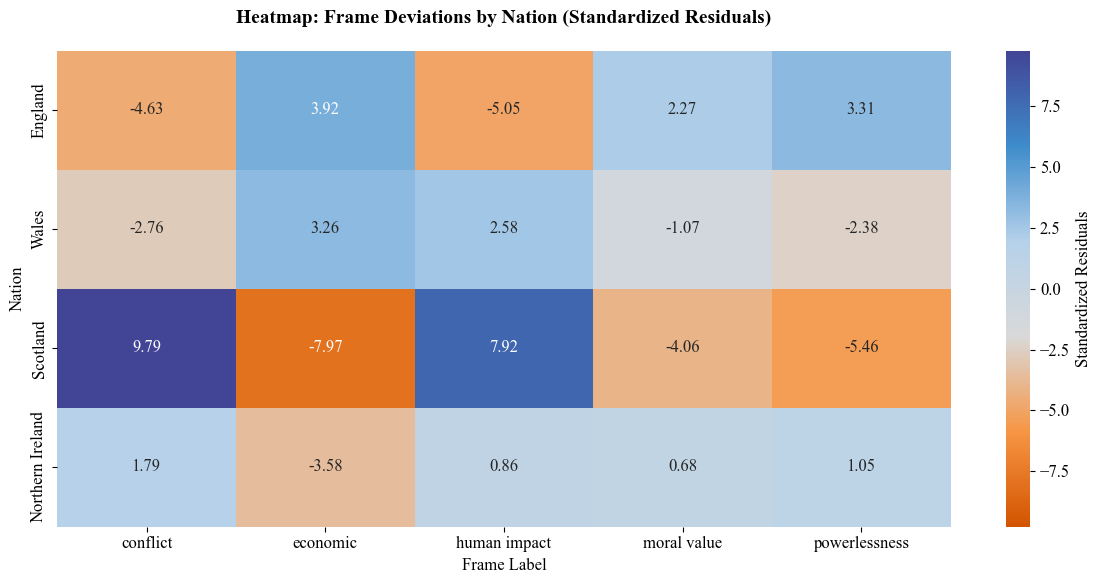

In [84]:
# ------------------------------------------------------------
# Standardized residuals heatmap showing over/underrepresentation of frame labels within each UK nation.
# ------------------------------------------------------------

# Prepare dataset (exclude frame 'none' if present)
df_resid = df_geo_valid.copy()
df_resid = df_resid[df_resid['frame_label'].str.lower() != 'none']

# Contingency table: Nation × Frame
cont_table = pd.crosstab(df_resid['nation'], df_resid['frame_label'])

# Chi-square test to obtain expected counts
chi2, p, dof, expected = chi2_contingency(cont_table)

# Standardized residuals
std_residuals = (cont_table - expected) / np.sqrt(expected)
resid_df = pd.DataFrame(
    std_residuals,
    index=cont_table.index,
    columns=cont_table.columns
)

# Optional ordering
nation_order = ["England", "Wales", "Scotland", "Northern Ireland"]
frame_order = sorted(resid_df.columns)
resid_df = resid_df.reindex(index=nation_order, columns=frame_order)

# Set font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

# Create custom colormap using your colors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import TwoSlopeNorm

# Define colors
LIGHT_GREEN = "#B4F3D0"
GREEN = "#00DF87"
LIGHT_BLUE = "#B5D1EA"
SKY_BLUE = "#8ACFDF"
BLUE = "#3E8CCB"
DARK_BLUE = "#424496"
YELLOW_HIGHLIGHT = "#EFD292"
ORANGE_HIGHLIGHT = "#F79645"
PURPLE = "#AD8BC9"
DARK_GREY = "#4D4D4D"
MEDIUM_GREY = "#646464"
GREY = "#A0A0A0"
LIGHT_GREY = "#BFBFBF"
VERY_LIGHT_GREY = "#D9D9D9"

# Create diverging colormap: dark orange (very negative) → light orange → grey (zero) → light blue → dark blue (very positive)
colors = ["#D35400", ORANGE_HIGHLIGHT, VERY_LIGHT_GREY, LIGHT_BLUE, BLUE, DARK_BLUE]
n_bins = 256
cmap = LinearSegmentedColormap.from_list('custom_diverging', colors, N=n_bins)

# Get min and max values for symmetric scale
vmin = resid_df.min().min()
vmax = resid_df.max().max()
abs_max = max(abs(vmin), abs(vmax))

# Plot heatmap with symmetric normalization
plt.figure(figsize=(12, 6))
sns.heatmap(
    resid_df,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    center=0,
    vmin=-abs_max,
    vmax=abs_max,
    cbar_kws={'label': 'Standardized Residuals'},
    annot_kws={'fontsize': 12}
)
plt.title("Heatmap: Frame Deviations by Nation (Standardized Residuals)", 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Frame Label", fontsize=12)
plt.ylabel("Nation", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Colorbar font size
cbar = plt.gca().collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Standardized Residuals', fontsize=12)

plt.tight_layout()
plt.show()